# Dataset taken Kaggle

**Credit card Fraud detection**

The dataset used in this project is the Credit Card Fraud Detection dataset, publicly available on Kaggle. It contains anonymized credit card transactions made by European cardholders over a two-day period in September 2013. The dataset is widely used in research and machine learning projects focused on fraud detection due to its real-world characteristics and severe class imbalance.

Source:
https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud


**Justification for Dataset Selection**

This dataset was selected because:

It represents a real-world financial fraud detection problem.
It is publicly available and widely recognized for benchmarking fraud detection models.
It contains a significant class imbalance, reflecting real banking scenarios where fraudulent transactions are rare.
It is suitable for evaluating different supervised machine learning algorithms and handling imbalanced data.



**Dataset Overview**


Dataset Name:	Credit Card Fraud Detection

Source:	Kaggle

Domain:	Finance

Machine Learning Task:	Binary Classification

Number of Records:	284,807

Number of Features:	30 input features + 1 target variable

Target Variable:	Class

Fraudulent Transactions:	492

Legitimate Transactions:	284,315

Fraud Percentage:	0.172%

File Format:	CSV

**Class Distribution**

0	Legitimate Transaction	284,315

1	Fraudulent Transaction	492



The dataset is highly imbalanced, with fraudulent transactions representing only 0.172% of all transactions. This imbalance presents a significant challenge and requires appropriate evaluation metrics and sampling techniques during model development.






**Feature Description**

**Time** – Seconds elapsed between each transaction and the first transaction in the dataset.

**Amount** – Transaction amount in Euros (€).

**V1–V28** – Principal Component Analysis (PCA) transformed numerical features. The original feature names have been anonymized for confidentiality.

**Class** – Binary target variable indicating whether a transaction is legitimate (0) or fraudulent (1).


**Duplicate Records**

Duplicate records will be identified using the duplicated() function in Pandas.

If duplicates are found, they will be removed before model training to prevent bias and redundant learning.



**Outlier Analysis**

The dataset contains several extreme values, particularly in the Amount feature.

Examples include:

Very small transactions
High-value transactions
Fraudulent transactions occurring across a wide range of amounts

**Outliers will be explored using:**

Boxplots
Histograms
Interquartile Range (IQR)

Since fraudulent transactions may naturally appear as outliers, they will not be removed indiscriminately


**Data Dictionary: **

All float, except class which is integer 0=legitimate,  1=Frtaud



<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

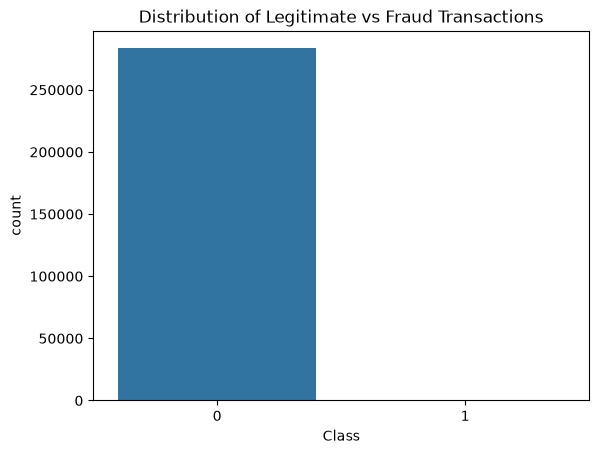

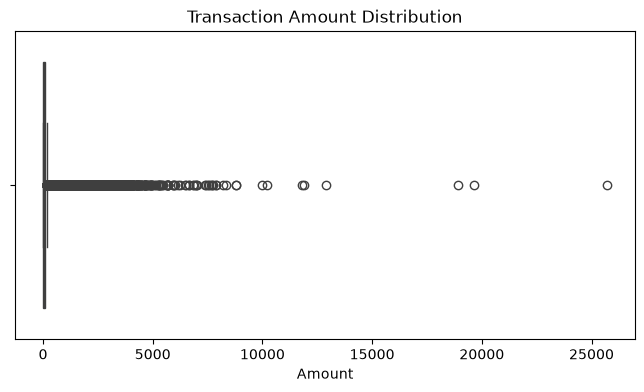

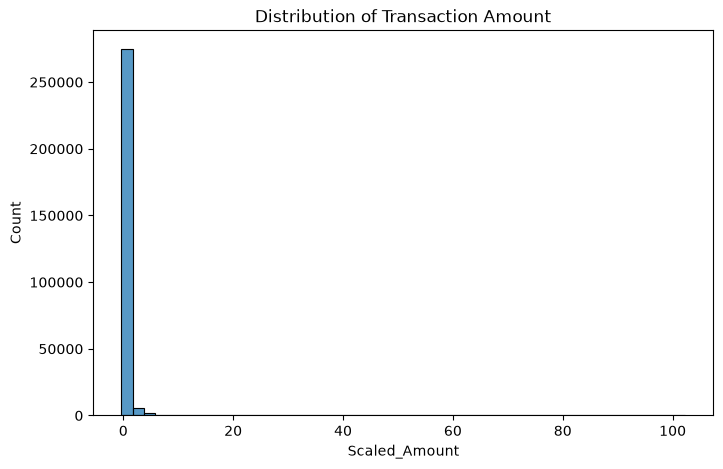

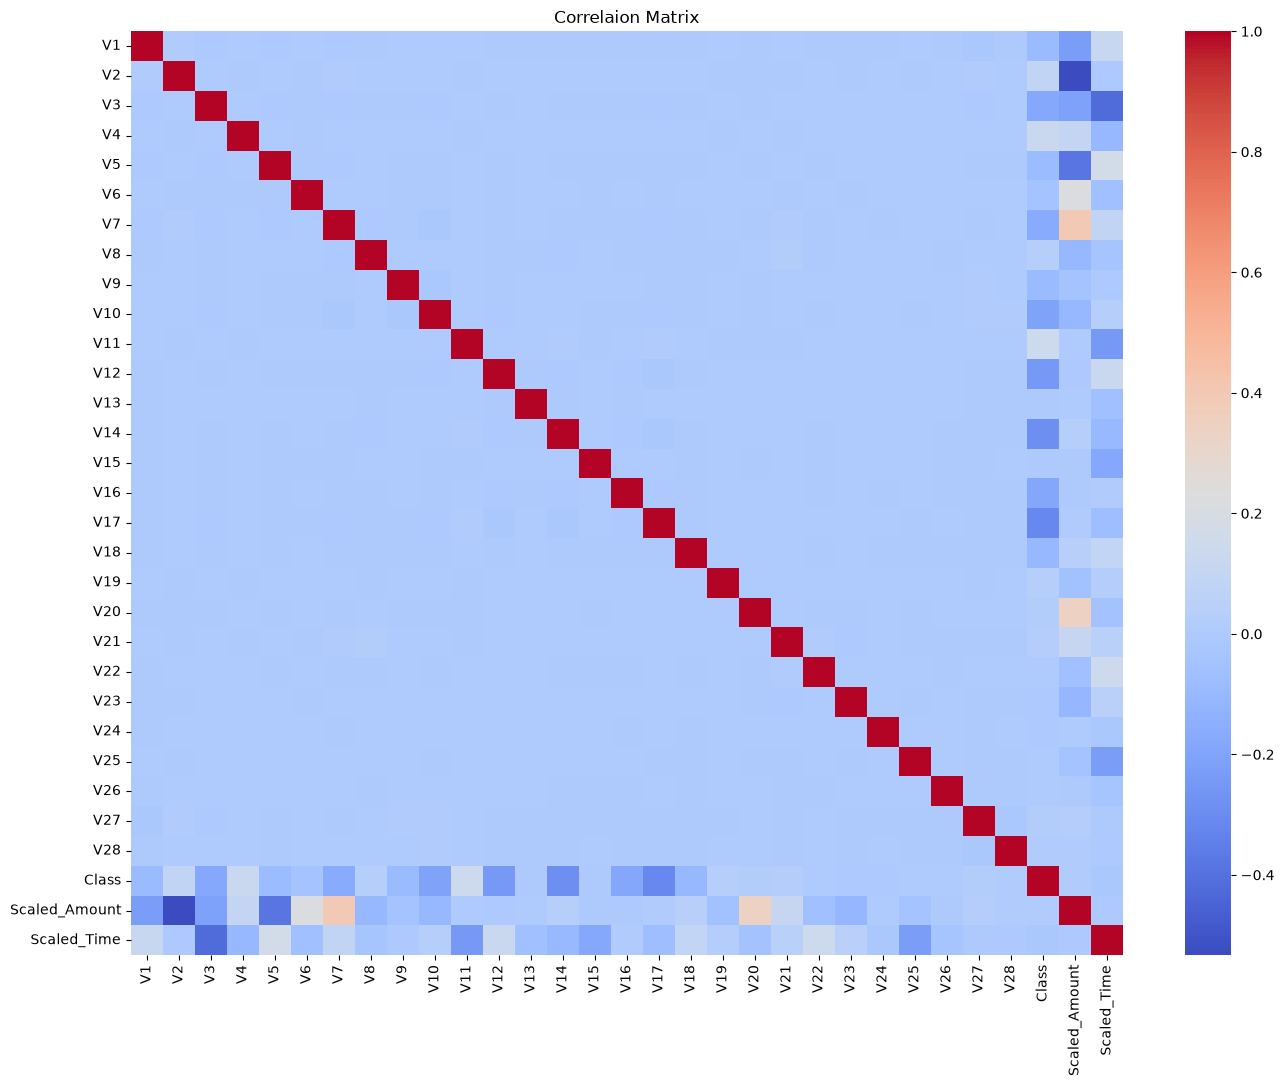

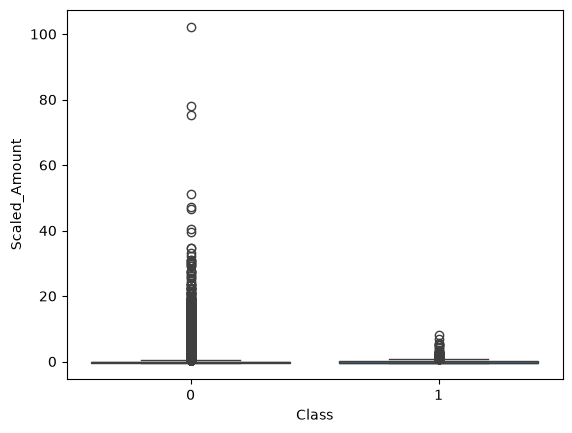

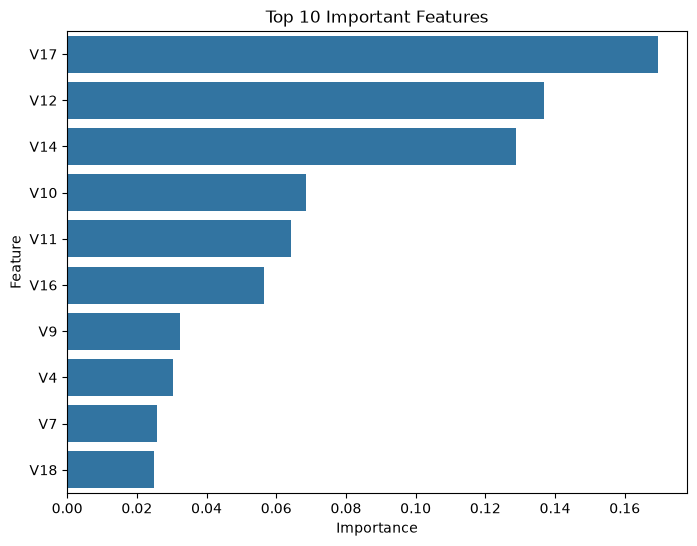

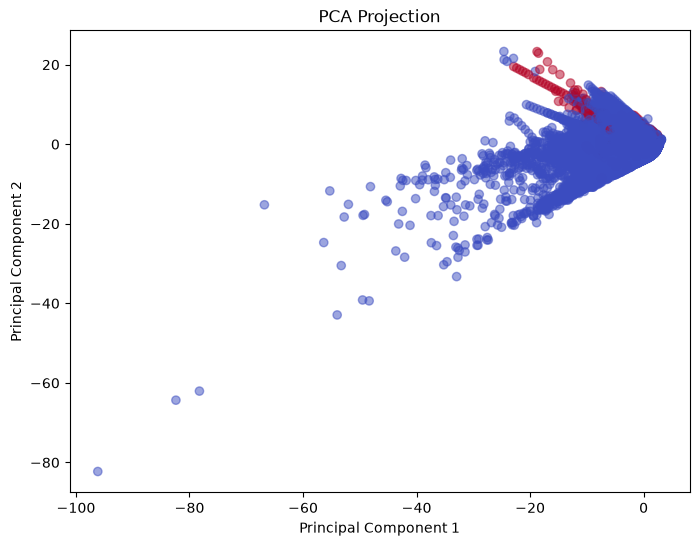

Processed dataset saved to: C:\Users\USER\.copilot\repos\copilot-worktrees\CapstoneProject\ramp8509-fictional-spork\data\creditcard_processed.csv
PC1 Explained Variance: 11.88%
PC2 Explained Variance: 10.13%
Total Retained Variance: 22.02%


In [ ]:
#Step 2: Data Collection & Understanding
#Step 3: Data Preprocessing, EDA & Feature Engineering


from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif

from sklearn.ensemble import RandomForestClassifier

import shap

# Load dataset
project_root = Path.cwd().resolve()
if "__file__" in globals():
    project_root = Path(__file__).resolve().parents[1]

for candidate in [project_root, *project_root.parents]:
    data_path = candidate / "data" / "creditcard.csv"
    if data_path.exists():
        project_root = candidate
        break
else:
    raise FileNotFoundError("Could not find project root or data/creditcard.csv.")

data_path = project_root / "data" / "creditcard.csv"
if not data_path.exists():
    raise FileNotFoundError(f"Could not find dataset at: {data_path}")

df = pd.read_csv(data_path)
df.head()

#Dataset Information
df.info()

#Check Missing Values
print("Missing Values:")
print(df.isnull().sum())

#Check Duplicate Records
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

#Remove duplicates
df = df.drop_duplicates()

#Check Class Imbalance
df["Class"].value_counts()
sns.countplot(x="Class", data=df)
plt.title("Distribution of Legitimate vs Fraud Transactions")
plt.show()
#The dataset is highly imbalanced, with fraudulent transactions representing less than 1% of all observations. 
#This imbalance will be addressed later using SMOTE during model training.

#Outlier Detection
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Amount"])
plt.title("Transaction Amount Distribution")
plt.show()
#The Amount feature contains several extreme values. However, these observations may represent genuine high-value transactions or fraud 
# and should not be removed without careful consideration.

#Scale Numerical Features 
scaler = StandardScaler()
df["Scaled_Amount"] = scaler.fit_transform(df[["Amount"]])
df["Scaled_Time"] = scaler.fit_transform(df[["Time"]])

#Standardization ensures numerical variables have similar scales, improving the performance of algorithms such as Logistic Regression and Support Vector Machines.
df.drop(["Amount","Time"], axis=1, inplace=True)

#Exploratory Data Analysis (EDA)
plt.figure(figsize=(8,5))
sns.histplot(df["Scaled_Amount"], bins=50)
plt.title("Distribution of Transaction Amount")
plt.show()
#Most transactions involve relatively small amounts, while a small number of high-value transactions create a right-skewed distribution.

#Correlation Heatmap

plt.figure(figsize=(16,12))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlaion Matrix")
plt.show()
#Most PCA-transformed variables exhibit weak correlations, indicating successful dimensionality reduction and low multicollinearity.

#Fraud vs Amount
sns.boxplot(x="Class", y="Scaled_Amount", data=df)
plt.show()
#Observation: Fraudulent transactions occur across a wide range of transaction amounts, indicating that amount alone is insufficient for distinguishing fraud.

#Feature Engineering

df["Amount_Category"] = pd.qcut(
    df["Scaled_Amount"],
    q=4,
    labels=["Low","Medium","High","Very High"]
)

df["Amount_Category"] = df["Amount_Category"].astype("category").cat.codes
#Binning transaction amounts into quartiles may help capture non-linear relationships between transaction value and fraud risk.

#Feature Importance -Random Forest Importance


X = df.drop("Class", axis=1)

y = df["Class"]

rf = RandomForestClassifier(random_state=42)

rf.fit(X, y)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()
#The Random Forest model identifies the most influential variables contributing to fraud prediction. These features will guide feature selection and improve model interpretability.

#Features with larger absolute SHAP values have a greater influence on identifying fraudulent transactions.

#Feature Selection - SelectKBest (Filter Method)

selector = SelectKBest(
    score_func=mutual_info_classif,
    k=15
)

X_new = selector.fit_transform(X, y)

selected_features = X.columns[
    selector.get_support()
]

selected_features

#Mutual Information evaluates the dependency between each feature and the target variable. 
#The top 15 features are retained to reduce noise and computational complexity while preserving predictive power.


#Dimensionality Reduction

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    alpha=0.5,
    cmap="coolwarm"
)

plt.title("PCA Projection")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.show()

#PCA was applied to reduce the feature space to two principal components for visualization. While the original dataset already contains 
#PCA-transformed variables, this additional projection provides an intuitive view of the overall data structure and potential class separation.

# Save processed dataset for model implementation

processed_data_path = project_root / "data" / "creditcard_processed.csv"

df.to_csv(processed_data_path, index=False)

print(f"Processed dataset saved to: {processed_data_path}")


# Calculate and print explained variance
var_ratio = pca.explained_variance_ratio_
print(f"PC1 Explained Variance: {var_ratio[0]*100:.2f}%")
print(f"PC2 Explained Variance: {var_ratio[1]*100:.2f}%")
print(f"Total Retained Variance: {sum(var_ratio)*100:.2f}%")


Logistic Regression Results
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746

Confusion Matrix:
[[55167  1484]
 [   12    83]]

Decision Tree Results
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56651
           1       0.09      0.78      0.16        95

    accuracy                           0.99     56746
   macro avg       0.54      0.88      0.58     56746
weighted avg       1.00      0.99      0.99     56746

Confusion Matrix:
[[55886   765]
 [   21    74]]

Random Forest Results
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.94      0.77      0.84        95

    accur

C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



SVM Results
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56651
           1       0.10      0.86      0.17        95

    accuracy                           0.99     56746
   macro avg       0.55      0.92      0.58     56746
weighted avg       1.00      0.99      0.99     56746

Confusion Matrix:
[[55890   761]
 [   13    82]]

Model Comparison:
                    Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0     Logistic Regression  0.973637   0.052967  0.873684  0.099880  0.962211
4  Support Vector Machine  0.986360   0.097272  0.863158  0.174840  0.972642
3                 XGBoost  0.999225   0.757576  0.789474  0.773196  0.974710
1           Decision Tree  0.986149   0.088200  0.778947  0.158458  0.833258
2           Random Forest  0.999524   0.935897  0.768421  0.843931  0.961682


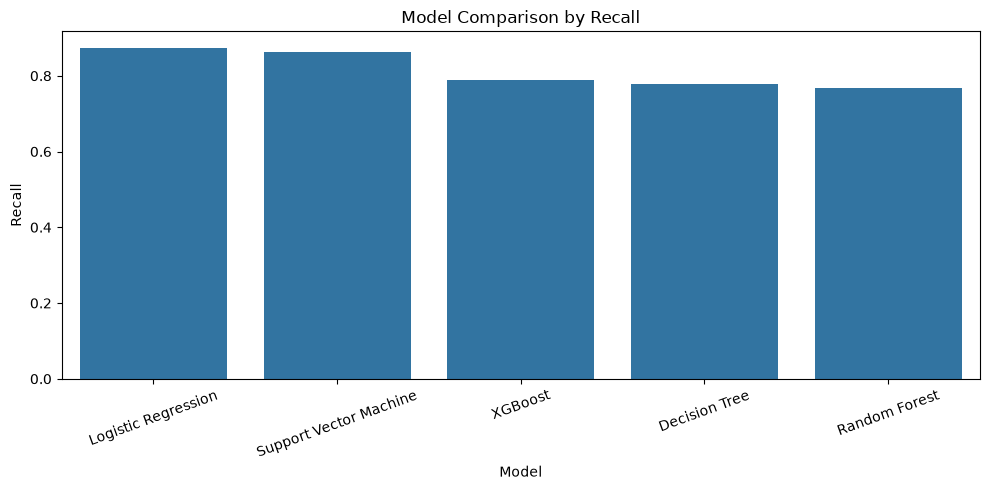


Models and comparison results saved successfully.


In [2]:
# Step 4: Model Implementation for Fraud Detection

from pathlib import Path
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report)

from imblearn.over_sampling import SMOTE

# Load processed dataset saved from Step 3
project_root = Path.cwd().resolve()
if "__file__" in globals():
    project_root = Path(__file__).resolve().parents[1]

for candidate in [project_root, *project_root.parents]:
    data_path = candidate / "data" / "creditcard_processed.csv"
    if data_path.exists():
        project_root = candidate
        break
else:
    raise FileNotFoundError("Could not find project root or data/creditcard_processed.csv.")

data_path = project_root / "data" / "creditcard_processed.csv"
df = pd.read_csv(data_path)

# Separate features (X) and target (y)
X = df.drop("Class", axis=1)
y = df["Class"]

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Handle class imbalance with SMOTE (on training data only)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Function to train and evaluate models
def evaluate_model(name, model):
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc = roc_auc_score(y_test, y_prob) if y_prob is not None else "N/A"

    print(f"\n{name} Results")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC-AUC": roc
    }

# Train and evaluate models
results = []

# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
results.append(evaluate_model("Logistic Regression", log_reg))

# Decision Tree
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
results.append(evaluate_model("Decision Tree", dt))

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
results.append(evaluate_model("Random Forest", rf))

# XGBoost
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
results.append(evaluate_model("XGBoost", xgb))

# Support Vector Machine (SVM) on smaller subset for efficiency
svm = SVC(probability=True, random_state=42)
X_train_smote

# SVM training on a smaller subset (for efficiency)
sample_size = min(30000, len(X_train_smote))
X_train_svm = X_train_smote.sample(sample_size, random_state=42)
y_train_svm = y_train_smote.loc[X_train_svm.index]

svm = SVC(probability=True, random_state=42)
svm.fit(X_train_svm, y_train_svm)
y_pred_svm = svm.predict(X_test)
y_prob_svm = svm.predict_proba(X_test)[:, 1]

results.append({
    "Model": "Support Vector Machine",
    "Accuracy": accuracy_score(y_test, y_pred_svm),
    "Precision": precision_score(y_test, y_pred_svm, zero_division=0),
    "Recall": recall_score(y_test, y_pred_svm, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_svm, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob_svm)
})

print("\nSVM Results")
print(classification_report(y_test, y_pred_svm, zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

# Create a DataFrame to compare all models
results_df = pd.DataFrame(results).sort_values(by="Recall", ascending=False)

# Print the comparison table
print("\nModel Comparison:")
print(results_df)

# Optional: Plot the Recall for each model
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Model", y="Recall")
plt.xticks(rotation=20)
plt.title("Model Comparison by Recall")
plt.tight_layout()
plt.show()

# Save models and results
models_dir = project_root / "models"
models_dir.mkdir(exist_ok=True)

joblib.dump(log_reg, models_dir / "logistic_regression.pkl")
joblib.dump(dt, models_dir / "decision_tree.pkl")
joblib.dump(rf, models_dir / "random_forest.pkl")
joblib.dump(xgb, models_dir / "xgboost.pkl")
joblib.dump(svm, models_dir / "svm.pkl")

results_df.to_csv(models_dir / "model_comparison.csv", index=False)

print("\nModels and comparison results saved successfully.")